# Retail Sector Market Research — Analysis Walkthrough

A narrative tour of the pipeline's key findings. Every number and figure below is
produced live from the cleaned transaction data by the `sector_research` package —
the same code that powers the automated report.

> Run the pipeline first (`make pipeline`) so the processed data exists, then
> execute this notebook top-to-bottom.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from sector_research.config import load_config
from sector_research.data.clean import load_clean
from sector_research.features.rfm import build_customer_features, rfm_scores

cfg = load_config()
df = load_clean(cfg)
print(f"{len(df):,} clean transaction lines "
      f"({df['invoice_date'].min().date()} -> {df['invoice_date'].max().date()})")
df.head()

776,840 clean transaction lines (2009-12-01 -> 2011-12-09)


,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,revenue,order_date,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12


## 1. Market at a glance

Headline KPIs for the whole two-year window.

In [2]:
from sector_research.analysis.eda import market_overview
kpis = market_overview(df)
pd.Series({
    "Total revenue":      f"£{kpis['total_revenue']:,.0f}",
    "Orders":             f"{kpis['orders']:,}",
    "Active customers":   f"{kpis['customers']:,}",
    "Distinct products":  f"{kpis['products']:,}",
    "Countries":          kpis['countries'],
    "Avg order value":    f"£{kpis['avg_order_value']:,.0f}",
}, name="value").to_frame()

,value
Total revenue,"£17,082,086"
Orders,"36,613"
Active customers,"5,853"
Distinct products,"4,624"
Countries,41
Avg order value,£467


## 2. Where does the money come from?

Revenue is highly concentrated — a classic Pareto profile that should shape retention strategy.

Top 20% of customers (1,170 people) drive 77.2% of revenue.


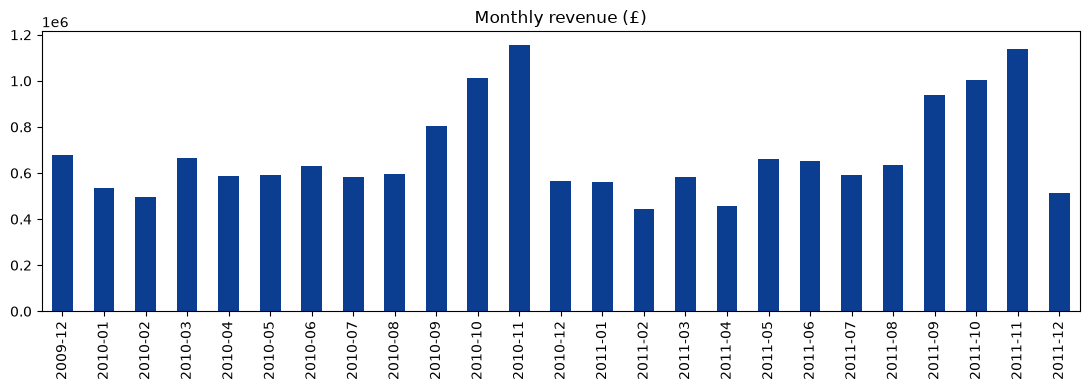

In [3]:
cust_rev = df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
top20 = int(len(cust_rev) * 0.2)
print(f"Top 20% of customers ({top20:,} people) drive "
      f"{cust_rev.head(top20).sum() / cust_rev.sum():.1%} of revenue.")

monthly = df.groupby("year_month")["revenue"].sum()
ax = monthly.plot(kind="bar", figsize=(11, 4), color="#0B3D91",
                  title="Monthly revenue (£)")
ax.set_xlabel(""); ax.figure.tight_layout()

## 3. Customer segmentation (RFM → K-Means)

We engineer Recency / Frequency / Monetary features per customer, then let K-Means find natural groups. Personas are assigned by each cluster's value rank.

In [4]:
from sector_research.models.segmentation import fit_segments, segment_profile

feats = rfm_scores(build_customer_features(df, cfg))
segmented, _ = fit_segments(feats, cfg)
profile = segment_profile(segmented)
profile[["persona", "customers", "customer_share", "revenue_share", "monetary"]]     .style.format({"customer_share": "{:.1%}", "revenue_share": "{:.1%}",
                   "monetary": "£{:,.0f}"})     .set_caption("Champions are a fifth of customers but the majority of revenue")

05:01:05 | INFO    | sector_research.features.rfm | Built features for 5,853 customers


,persona,customers,customer_share,revenue_share,monetary
0,Champions,1186,20.3%,73.9%,"£4,908"
1,Loyal Customers,1452,24.8%,16.3%,"£1,453"
3,Potential / Recent,1246,21.3%,6.1%,£720
2,At-Risk / Dormant,1969,33.6%,3.7%,£276


## 4. Retention is the real problem

Monthly acquisition cohorts show how quickly new customers lapse.

In [5]:
from sector_research.analysis.cohort import build_cohorts
retention = build_cohorts(df)
avg = retention.drop(columns=[0]).mean()
print(f"Average month-1 retention: {retention[1].mean():.1%}")
print(f"Average month-3 retention: {retention[3].mean():.1%}")
retention.iloc[:6, :8].style.format("{:.0%}", na_rep="")     .background_gradient(cmap="YlGnBu", axis=None)     .set_caption("Retention triangle (first 6 cohorts)")

Average month-1 retention: 21.0%
Average month-3 retention: 21.7%


offset,0,1,2,3,4,5,6,7
cohort,,,,,,,,
2009-12,100%,35%,33%,43%,38%,36%,38%,34%
2010-01,100%,21%,32%,32%,27%,31%,27%,23%
2010-02,100%,23%,23%,29%,25%,20%,19%,29%
2010-03,100%,19%,23%,24%,23%,20%,25%,31%
2010-04,100%,19%,19%,16%,18%,22%,28%,27%
2010-05,100%,16%,17%,18%,18%,25%,21%,13%


## 5. What sells together? (market-basket analysis)

Association rules surface high-lift product pairs for bundling and cross-sell.

In [6]:
from sector_research.analysis.market_basket import mine_rules
rules = mine_rules(df, cfg)
rules.head(8).style.format({"support": "{:.3f}", "confidence": "{:.1%}", "lift": "{:.1f}"})

05:01:09 | INFO    | sector_research.analysis.market_basket | Mining rules on 33,374 baskets × 5,199 products (United Kingdom)


,antecedents_str,consequents_str,support,confidence,lift
0,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.023,68.9%,13.9
1,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,0.023,45.6%,13.9
2,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.029,60.3%,11.7
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.029,56.5%,11.7
4,LOVE BUILDING BLOCK WORD,HOME BUILDING BLOCK WORD,0.023,52.8%,10.0
5,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,0.023,43.2%,10.0
6,HEART OF WICKER LARGE,HEART OF WICKER SMALL,0.026,49.7%,9.6
7,HEART OF WICKER SMALL,HEART OF WICKER LARGE,0.026,49.4%,9.6


## 6. Predicting churn

A gradient-boosted model, trained only on pre-cutoff behaviour, flags who will lapse in the next 90 days. Recency dominates — unsurprising, but the model adds meaningful lift over that single signal.

In [7]:
from sector_research.models.churn import build_churn_frame
churn_df, cutoff = build_churn_frame(df, cfg)
print(f"Cutoff {cutoff.date()} | churn rate {churn_df['churned'].mean():.1%} "
      f"over {cfg['churn']['inactivity_days']} days")
churn_df.groupby("churned")[["recency", "frequency", "monetary"]].median()     .rename(index={0: "retained", 1: "churned"})

05:01:23 | INFO    | sector_research.features.rfm | Built features for 5,257 customers


05:01:23 | INFO    | sector_research.models.churn | Churn frame: 5,257 customers active before 2011-09-10; churn rate 56.5% over the next 90 days


Cutoff 2011-09-10 | churn rate 56.5% over 90 days


,recency,frequency,monetary
churned,,,
retained,68.0,5.0,1583.47
churned,286.0,2.0,477.44


## Takeaways

1. **Revenue is concentrated** — protect the top 20% before chasing new acquisition.
2. **Retention, not traffic, is the ceiling** — month-1 retention near 20% is the biggest leak.
3. **Cross-sell is real** — several product pairs sell together at >10× lift.
4. **Churn is predictable** (ROC-AUC ≈ 0.81) — the model turns insight into a monthly action list.

See [`reports/executive_summary.md`](../reports/executive_summary.md) for the full write-up.
